# **Install Library**

In [1]:
!pip install tensorflow tensorflowjs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 3.6 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 24.2
    Uninstalling packaging-24.2:
      Successfully uninstalled packaging-24.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
db-dtypes 1.4.3 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
google-cloud-bigquery 3.34.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.


# **Import Library**

In [2]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tqdm import tqdm

# **Download Dataset Fruits-360**

In [3]:
!wget https://github.com/Horea94/Fruit-Images-Dataset/archive/master.zip
!unzip -q master.zip
!rm master.zip

--2025-06-06 03:34:33--  https://github.com/Horea94/Fruit-Images-Dataset/archive/master.zip
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/Horea94/Fruit-Images-Dataset/zip/refs/heads/master [following]
--2025-06-06 03:34:33--  https://codeload.github.com/Horea94/Fruit-Images-Dataset/zip/refs/heads/master
Resolving codeload.github.com (codeload.github.com)... 140.82.116.9
Connecting to codeload.github.com (codeload.github.com)|140.82.116.9|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘master.zip’

master.zip              [        <=>         ] 761.30M  30.2MB/s    in 27s     

2025-06-06 03:35:01 (27.9 MB/s) - ‘master.zip’ saved [798281972]



# **Gabungkan Semua Gambar ke Folder**

In [4]:
src_train = 'Fruit-Images-Dataset-master/Training'
src_test = 'Fruit-Images-Dataset-master/Test'
merged_dir = 'merged_dataset'

if not os.path.exists(merged_dir):
    os.makedirs(merged_dir)

for src in [src_train, src_test]:
    for class_name in os.listdir(src):
        class_path = os.path.join(src, class_name)
        if os.path.isdir(class_path):
            dst_class_path = os.path.join(merged_dir, class_name)
            os.makedirs(dst_class_path, exist_ok=True)
            for fname in os.listdir(class_path):
                shutil.copy(os.path.join(class_path, fname), os.path.join(dst_class_path, fname))

# **Split Dataset**

In [5]:
from glob import glob

dataset_dir = 'merged_dataset'
output_base = 'dataset_split'

filepaths = []
labels = []

for class_dir in os.listdir(dataset_dir):
    class_path = os.path.join(dataset_dir, class_dir)
    for img_file in os.listdir(class_path):
        filepaths.append(os.path.join(class_path, img_file))
        labels.append(class_dir)

train_files, temp_files, train_labels, temp_labels = train_test_split(
    filepaths, labels, stratify=labels, test_size=0.3, random_state=42)

val_files, test_files, val_labels, test_labels = train_test_split(
    temp_files, temp_labels, stratify=temp_labels, test_size=0.5, random_state=42)

def move_files(files, labels, subset):
    for f, l in tqdm(zip(files, labels), total=len(files), desc=f"Copying {subset}"):
        dst_dir = os.path.join(output_base, subset, l)
        os.makedirs(dst_dir, exist_ok=True)
        shutil.copy(f, os.path.join(dst_dir, os.path.basename(f)))

move_files(train_files, train_labels, 'train')
move_files(val_files, val_labels, 'val')
move_files(test_files, test_labels, 'test')

Copying test: 100%|██████████| 13557/13557 [00:01<00:00, 8426.48it/s]


# **Data Generator**

In [6]:
IMG_SIZE = (100, 100)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./255)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(output_base, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_gen = val_test_datagen.flow_from_directory(
    os.path.join(output_base, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_gen = val_test_datagen.flow_from_directory(
    os.path.join(output_base, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 63262 images belonging to 131 classes.
Found 13556 images belonging to 131 classes.
Found 13557 images belonging to 131 classes.


# **CNN Model (Sequential, Conv2D, Pooling)**

In [7]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(100, 100, 3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(train_gen.num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 131)            │        16,899 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,748,675 (6.67 MB)

 Trainable params: 1,748,675 (6.67 MB)

 Non-trainable params: 0 (0.00 B)

# **Train Model**

In [8]:
history = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
1977/1977 ━━━━━━━━━━━━━━━━━━━━ 1103s 557ms/step - accuracy: 0.6995 - loss: 1.2779 - val_accuracy: 0.9896 - val_loss: 0.0393
Epoch 2/10
1977/1977 ━━━━━━━━━━━━━━━━━━━━ 1108s 560ms/step - accuracy: 0.9883 - loss: 0.0418 - val_accuracy: 0.9897 - val_loss: 0.0371
Epoch 3/10
1977/1977 ━━━━━━━━━━━━━━━━━━━━ 1085s 549ms/step - accuracy: 0.9878 - loss: 0.0453 - val_accuracy: 0.9866 - val_loss: 0.1054
Epoch 4/10
1977/1977 ━━━━━━━━━━━━━━━━━━━━ 1097s 555ms/step - accuracy: 0.9921 - loss: 0.0288 - val_accuracy: 0.9869 - val_loss: 0.0552
Epoch 5/10
1977/1977 ━━━━━━━━━━━━━━━━━━━━ 1064s 538ms/step - accuracy: 0.9913 - loss: 0.0324 - val_accuracy: 0.9906 - val_loss: 0.0270
Epoch 6/10
1977/1977 ━━━━━━━━━━━━━━━━━━━━ 1087s 550ms/step - accuracy: 0.9943 - loss: 0.0218 - val_accuracy: 0.9999 - val_loss: 0.0030
Epoch 7/10
1977/1977 ━━━━━━━━━━━━━━━━━━━━ 1060s 536ms/step - accuracy: 0.9959 - loss: 0.0167 - val_accuracy: 0.9911 - val_loss: 0.0292
Epoch 8/10
1977/1977 ━━━━━━━━━━━━━━━━━━━━ 1058s 535ms/s

# **Evaluasi Model (Testing)**

In [9]:
loss, acc = model.evaluate(test_gen)
print(f"Test Accuracy: {acc*100:.2f}%")

424/424 ━━━━━━━━━━━━━━━━━━━━ 66s 155ms/step - accuracy: 0.9998 - loss: 0.0010
Test Accuracy: 99.96%


# **Plot Akurasi dan Loss**

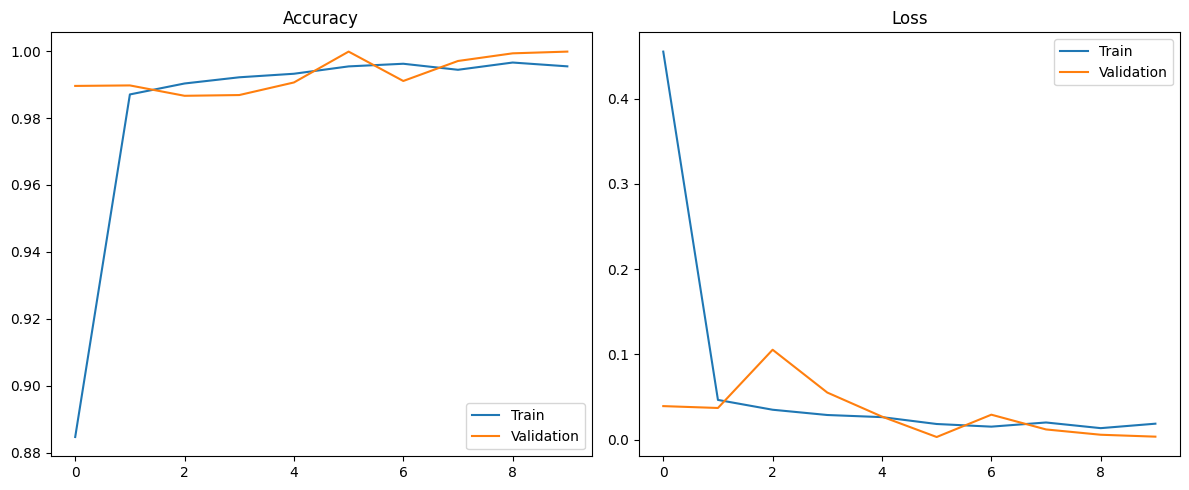

In [10]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# **Simpan Model ke SavedModel, TFLite, dan TFJS**

In [11]:
# Export model ke SavedModel (untuk TFLite dan TFJS)
model.export("model_saved")

# Convert ke TFLite
converter = tf.lite.TFLiteConverter.from_saved_model("model_saved")
tflite_model = converter.convert()
with open("model.tflite", "wb") as f:
    f.write(tflite_model)

# Convert ke TFJS
!tensorflowjs_converter --input_format=tf_saved_model model_saved tfjs_model

Saved artifact at 'model_saved'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100, 100, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 131), dtype=tf.float32, name=None)
Captures:
  132448765521424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132448765522576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132448765520080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132448765515664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132448765515472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132448765522000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132448765522960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132448765521808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132448765523920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132448765524880: TensorSpec(shape=(), dtype=tf.resource, name=None)
2025-06-06 06:37:49

In [13]:
# Kompres SavedModel
!zip -r model_saved.zip model_saved

# Kompres TFJS model
!zip -r tfjs_model.zip tfjs_model

  adding: model_saved/ (stored 0%)
  adding: model_saved/assets/ (stored 0%)
  adding: model_saved/fingerprint.pb (stored 0%)
  adding: model_saved/saved_model.pb (deflated 85%)
  adding: model_saved/variables/ (stored 0%)
  adding: model_saved/variables/variables.index (deflated 63%)
  adding: model_saved/variables/variables.data-00000-of-00001 (deflated 6%)
  adding: tfjs_model/ (stored 0%)
  adding: tfjs_model/model.json (deflated 88%)
  adding: tfjs_model/group1-shard2of2.bin (deflated 6%)
  adding: tfjs_model/group1-shard1of2.bin (deflated 6%)


In [14]:
from google.colab import files

# Unduh SavedModel
files.download("model_saved.zip")

# Unduh TFJS Model
files.download("tfjs_model.zip")

# Unduh TFLite Model
files.download("model.tflite")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>